# Financial Modelling: Baseline VARX

This notebook establishes baseline performance for Vector ARX (VARX) models without emotion indices.

## Model Specification

The baseline VARX model includes:
- **Endogenous lags**: Lagged values of all target assets (cross-asset spillovers)
- **Exogenous controls**: Macro/financial control variables
- **No emotion indices**: All emotion-related lags set to 0

## Evaluation Metrics
- Cross-validation: MAE, RMSE (rolling window)
- Out-of-sample: MAE, RMSE, MAPE, R²
- Economic: Cumulative returns from trading strategy
- Statistical: Bootstrap confidence intervals, Granger causality tests

## Assets
- Bitcoin (r_btc)
- Gold (r_gold)
- S&P 500 (r_spx)

In [1]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set display options
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [2]:
# Import custom modules
from modules.finance.models.varx import (
    VARXLagSpec,
    automl_varx_optuna,
    make_varx_design_heterogeneous
)
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    diebold_mariano_test
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_model_comparison_bars
)

print("Modules imported successfully")

Modules imported successfully


## Load Data

Load the financial returns dataset and prepare for VARX modeling with cross-asset dynamics.

In [3]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Define columns
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Drop rows with missing targets
df_clean = df.dropna(subset=TARGET_COLS)

# Prepare endogenous DataFrame and exogenous controls DataFrame
Y_endog = df_clean[TARGET_COLS]
X_controls = df_clean[CONTROL_COLS].fillna(0)

print(f"Data shape: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"\nEndogenous variables: {TARGET_COLS}")
print(f"Exogenous controls: {CONTROL_COLS}")

Data shape: (104, 44)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00

Endogenous variables: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
Exogenous controls: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']


## Baseline VARX Configuration

Configure the VARX model:
- **p_range**: Endogenous (cross-asset) lag range to optimize
- **q_control_range**: Control variable lag range
- **No emotion indices**: All q_* emotion lags set to 0

In [4]:
# Baseline VARX configuration - NO emotion indices
BASELINE_CONFIG = {
    # Endogenous and control lag ranges
    'p_range': (1, 5),          # Endogenous (cross-asset) lags
    'q_control_range': (0, 3),  # Control lags
    
    # All emotion index families set to 0
    'q_ei_range': (0, 0),
    'q_epi_range': (0, 0),
    'q_epi_signed_range': (0, 0),
    'q_ccd_range': (0, 0),
    'q_intensity_range': (0, 0),
    'q_surprise_range': (0, 0),
    'q_split_range': (0, 0),
    
    # Optimization settings
    'n_trials': 300,
    'cv_initial': 60,
    'cv_step': 1,
    'cv_test': 1,
}

print("Baseline VARX Configuration:")
for key, value in BASELINE_CONFIG.items():
    print(f"  {key}: {value}")

Baseline VARX Configuration:
  p_range: (1, 5)
  q_control_range: (0, 3)
  q_ei_range: (0, 0)
  q_epi_range: (0, 0)
  q_epi_signed_range: (0, 0)
  q_ccd_range: (0, 0)
  q_intensity_range: (0, 0)
  q_surprise_range: (0, 0)
  q_split_range: (0, 0)
  n_trials: 300
  cv_initial: 60
  cv_step: 1
  cv_test: 1


## Train Baseline VARX Model

Train the VARX model jointly for all assets using Optuna optimization. The VARX captures cross-asset spillover effects through endogenous lags.

In [5]:
# Train baseline VARX model
print("Training baseline VARX model...")
print("="*60)

result = automl_varx_optuna(
    Y=Y_endog,
    X=X_controls,  # Only controls, no emotion indices
    p_range=BASELINE_CONFIG['p_range'],
    q_controls_range=BASELINE_CONFIG['q_control_range'],
    q_ei_range=BASELINE_CONFIG['q_ei_range'],
    q_epi_range=BASELINE_CONFIG['q_epi_range'],
    q_epi_signed_range=BASELINE_CONFIG['q_epi_signed_range'],
    q_ccd_range=BASELINE_CONFIG['q_ccd_range'],
    q_intensity_range=BASELINE_CONFIG['q_intensity_range'],
    q_surprise_range=BASELINE_CONFIG['q_surprise_range'],
    q_split_range=BASELINE_CONFIG['q_split_range'],
    n_trials=BASELINE_CONFIG['n_trials'],
    initial_train=BASELINE_CONFIG['cv_initial'],
    step=BASELINE_CONFIG['cv_step'],
    val_size=BASELINE_CONFIG['cv_test'],
)

# Store results
varx_results = {
    'best_lags': result['best_lags'],
    'best_model_params': result['best_model_params'],
    'fitted_pipeline': result['fitted_pipeline'],
    'cv_mae': result['best_score_mae'],
    'cv_rmse': result['best_score_rmse'],
    'coef_matrix': result['coef_matrix'],
    'feature_names': result['feature_names'],
    'Z_design': result['Z_design'],
    'Y_target': result['Y_target'],
}

print(f"\nBest VARX specification:")
print(f"  Endogenous lags (p): {result['best_lags'].p}")
print(f"  Control lags (q_controls): {result['best_lags'].q_controls}")
print(f"\nCV Scores:")
print(f"  MAE: {result['best_score_mae']:.6f}")
print(f"  RMSE: {result['best_score_rmse']:.6f}")

[I 2026-01-31 16:47:01,090] A new study created in memory with name: no-name-d32cfffa-ab04-4a5f-bfe6-e018434c1305


Training baseline VARX model...


Optuna VARX Optimization: 100%|██████████| 300/300 [00:37<00:00,  8.00it/s, best_mae=0.0146]


Best VARX specification:
  Endogenous lags (p): 2
  Control lags (q_controls): 1

CV Scores:
  MAE: 0.014612
  RMSE: 0.017173


## Out-of-Sample Evaluation

Generate rolling window out-of-sample predictions and compute evaluation metrics for each target asset.

In [6]:
# Use design matrix from stored results
Z_design = varx_results['Z_design']
Y_design = varx_results['Y_target']
feature_names = varx_results['feature_names']

print(f"Design matrix shape: {Z_design.shape}")
print(f"Target matrix shape: {Y_design.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}...")

Design matrix shape: (102, 24)
Target matrix shape: (102, 8)
Number of features: 24

Feature names: ['r_btc_lag1', 'r_gold_lag1', 'r_spx_lag1', 'r_spx_auto_lag1', 'r_spx_oilgas_lag1', 'r_spx_mach_lag1', 'r_spx_elec_lag1', 'r_aapl_lag1', 'r_btc_lag2', 'r_gold_lag2']...


In [7]:
# Generate OOS predictions using rolling window
from sklearn.base import clone

oos_predictions = {target: {'y_true': [], 'y_pred': [], 'dates': []} for target in TARGET_COLS}

initial_train = BASELINE_CONFIG['cv_initial']
step_size = BASELINE_CONFIG['cv_step']
test_size = BASELINE_CONFIG['cv_test']
n_samples = len(Y_design)

print("Generating out-of-sample predictions...")

# Get the fitted pipeline (MultiTaskElasticNet predicts all targets jointly)
pipeline = varx_results['fitted_pipeline']

for train_end in range(initial_train, n_samples - test_size + 1, step_size):
    test_start = train_end
    test_end = test_start + test_size
    
    Z_train = Z_design.iloc[:train_end].values
    Z_test = Z_design.iloc[test_start:test_end].values
    Y_train = Y_design.iloc[:train_end].values  # All targets jointly
    Y_test = Y_design.iloc[test_start:test_end].values
    
    # Clone pipeline and fit for all targets jointly (MultiTask)
    model = clone(pipeline)
    model.fit(Z_train, Y_train)
    
    # Predict all targets at once
    Y_pred = model.predict(Z_test)
    
    # Store predictions for each target
    for i, target in enumerate(TARGET_COLS):
        oos_predictions[target]['y_true'].extend(Y_test[:, i])
        oos_predictions[target]['y_pred'].extend(Y_pred[:, i])
        oos_predictions[target]['dates'].extend(
            Z_design.index[test_start:test_end].tolist()
        )

# Convert to DataFrames and compute metrics
oos_metrics = {}
for target in TARGET_COLS:
    oos_predictions[target] = pd.DataFrame({
        'date': oos_predictions[target]['dates'],
        'y_true': oos_predictions[target]['y_true'],
        'y_pred': oos_predictions[target]['y_pred']
    }).set_index('date')
    
    oos_metrics[target] = compute_all_metrics(
        np.array(oos_predictions[target]['y_true']),
        np.array(oos_predictions[target]['y_pred'])
    )

print("Done!")
for target in TARGET_COLS:
    print(f"  {target}: {len(oos_predictions[target])} OOS samples")

Generating out-of-sample predictions...
Done!
  r_btc: 42 OOS samples
  r_gold: 42 OOS samples
  r_spx: 42 OOS samples
  r_spx_auto: 42 OOS samples
  r_spx_oilgas: 42 OOS samples
  r_spx_mach: 42 OOS samples
  r_spx_elec: 42 OOS samples
  r_aapl: 42 OOS samples


In [8]:
# Display OOS metrics summary
print("\n" + "="*60)
print("OUT-OF-SAMPLE METRICS SUMMARY (VARX Baseline)")
print("="*60)

metrics_data = []
for target, metrics in oos_metrics.items():
    metrics_data.append({
        'Asset': target,
        'MAE': metrics['mae'],
        'RMSE': metrics['rmse'],
        'MAPE (%)': metrics['mape'],
        'R²': metrics['r2'],
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.style.format({
    'MAE': '{:.6f}',
    'RMSE': '{:.6f}',
    'MAPE (%)': '{:.2f}',
    'R²': '{:.4f}',
}))


OUT-OF-SAMPLE METRICS SUMMARY (VARX Baseline)


,Asset,MAE,RMSE,MAPE (%),R²
0,r_btc,0.015459,0.019315,302.33,0.0021
1,r_gold,0.009704,0.012368,79.04,-0.3671
2,r_spx,0.011546,0.018914,565.99,-0.1001
3,r_spx_auto,0.023629,0.035366,253.64,-0.0541
4,r_spx_oilgas,0.012714,0.020833,291.73,-0.0011
5,r_spx_mach,0.012263,0.020075,193.58,-0.1015
6,r_spx_elec,0.015773,0.023895,335.71,-0.0833
7,r_aapl,0.018877,0.029992,255.27,-0.1011


## Compare with ARX Baseline

Load ARX baseline results and compare using Diebold-Mariano test to determine if cross-asset information improves forecasting.

In [9]:
# Load ARX baseline results for comparison
arx_metrics_path = OUTPUT_DIR / 'arx_baseline_metrics.csv'

if arx_metrics_path.exists():
    arx_metrics_df = pd.read_csv(arx_metrics_path)
    
    print("Model Comparison: ARX vs VARX Baseline")
    print("="*60)
    
    comparison_data = []
    dm_results = {}
    
    for target in TARGET_COLS:
        arx_row = arx_metrics_df[arx_metrics_df['asset'] == target].iloc[0]
        varx_metrics = oos_metrics[target]
        
        # Load ARX predictions for DM test
        arx_pred_path = OUTPUT_DIR / f'arx_baseline_predictions_{target}.csv'
        if arx_pred_path.exists():
            arx_preds = pd.read_csv(arx_pred_path, index_col='date', parse_dates=True)
            varx_preds = oos_predictions[target]
            
            # Align dates
            common_dates = arx_preds.index.intersection(varx_preds.index)
            if len(common_dates) > 0:
                arx_aligned = arx_preds.loc[common_dates]
                varx_aligned = varx_preds.loc[common_dates]
                
                # Compute forecast errors
                arx_errors = arx_aligned['y_true'].values - arx_aligned['y_pred'].values
                varx_errors = varx_aligned['y_true'].values - varx_aligned['y_pred'].values
                
                # Diebold-Mariano test (comparing squared errors)
                dm_result = diebold_mariano_test(
                    arx_errors,
                    varx_errors,
                    loss_function='SE'
                )
                dm_results[target] = {'statistic': dm_result['statistic'], 'p_value': dm_result['pvalue']}
            else:
                dm_results[target] = {'statistic': None, 'p_value': None}
        else:
            dm_results[target] = {'statistic': None, 'p_value': None}
        
        comparison_data.append({
            'Asset': target,
            'ARX MAE': arx_row['oos_mae'],
            'VARX MAE': varx_metrics['mae'],
            'Δ MAE': varx_metrics['mae'] - arx_row['oos_mae'],
            'ARX RMSE': arx_row['oos_rmse'],
            'VARX RMSE': varx_metrics['rmse'],
            'Δ RMSE': varx_metrics['rmse'] - arx_row['oos_rmse'],
            'DM p-value': dm_results[target]['p_value']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.style.format({
        'ARX MAE': '{:.6f}', 'VARX MAE': '{:.6f}', 'Δ MAE': '{:+.6f}',
        'ARX RMSE': '{:.6f}', 'VARX RMSE': '{:.6f}', 'Δ RMSE': '{:+.6f}',
        'DM p-value': '{:.4f}'
    }))
    
    print("\nNote: Negative Δ means VARX is better. DM p-value < 0.05 indicates significant difference.")
else:
    print("ARX baseline results not found. Run 410_fm_baseline_arx.ipynb first.")

Model Comparison: ARX vs VARX Baseline


,Asset,ARX MAE,VARX MAE,Δ MAE,ARX RMSE,VARX RMSE,Δ RMSE,DM p-value
0,r_btc,0.015244,0.015459,+0.000215,0.019570,0.019315,-0.000255,0.9356
1,r_gold,0.009274,0.009704,+0.000430,0.011982,0.012368,+0.000386,0.8023
2,r_spx,0.009901,0.011546,+0.001645,0.015690,0.018914,+0.003224,0.7422
3,r_spx_auto,0.023059,0.023629,+0.000569,0.033674,0.035366,+0.001692,0.8568
4,r_spx_oilgas,0.010043,0.012714,+0.002671,0.014183,0.020833,+0.006650,0.3731
5,r_spx_mach,0.010355,0.012263,+0.001908,0.015926,0.020075,+0.004149,0.8023
6,r_spx_elec,0.012377,0.015773,+0.003396,0.018099,0.023895,+0.005796,0.6940
7,r_aapl,0.016622,0.018877,+0.002255,0.025526,0.029992,+0.004466,0.9118



Note: Negative Δ means VARX is better. DM p-value < 0.05 indicates significant difference.


## Cumulative Returns Analysis

Compute cumulative returns from trading strategies based on VARX predictions.

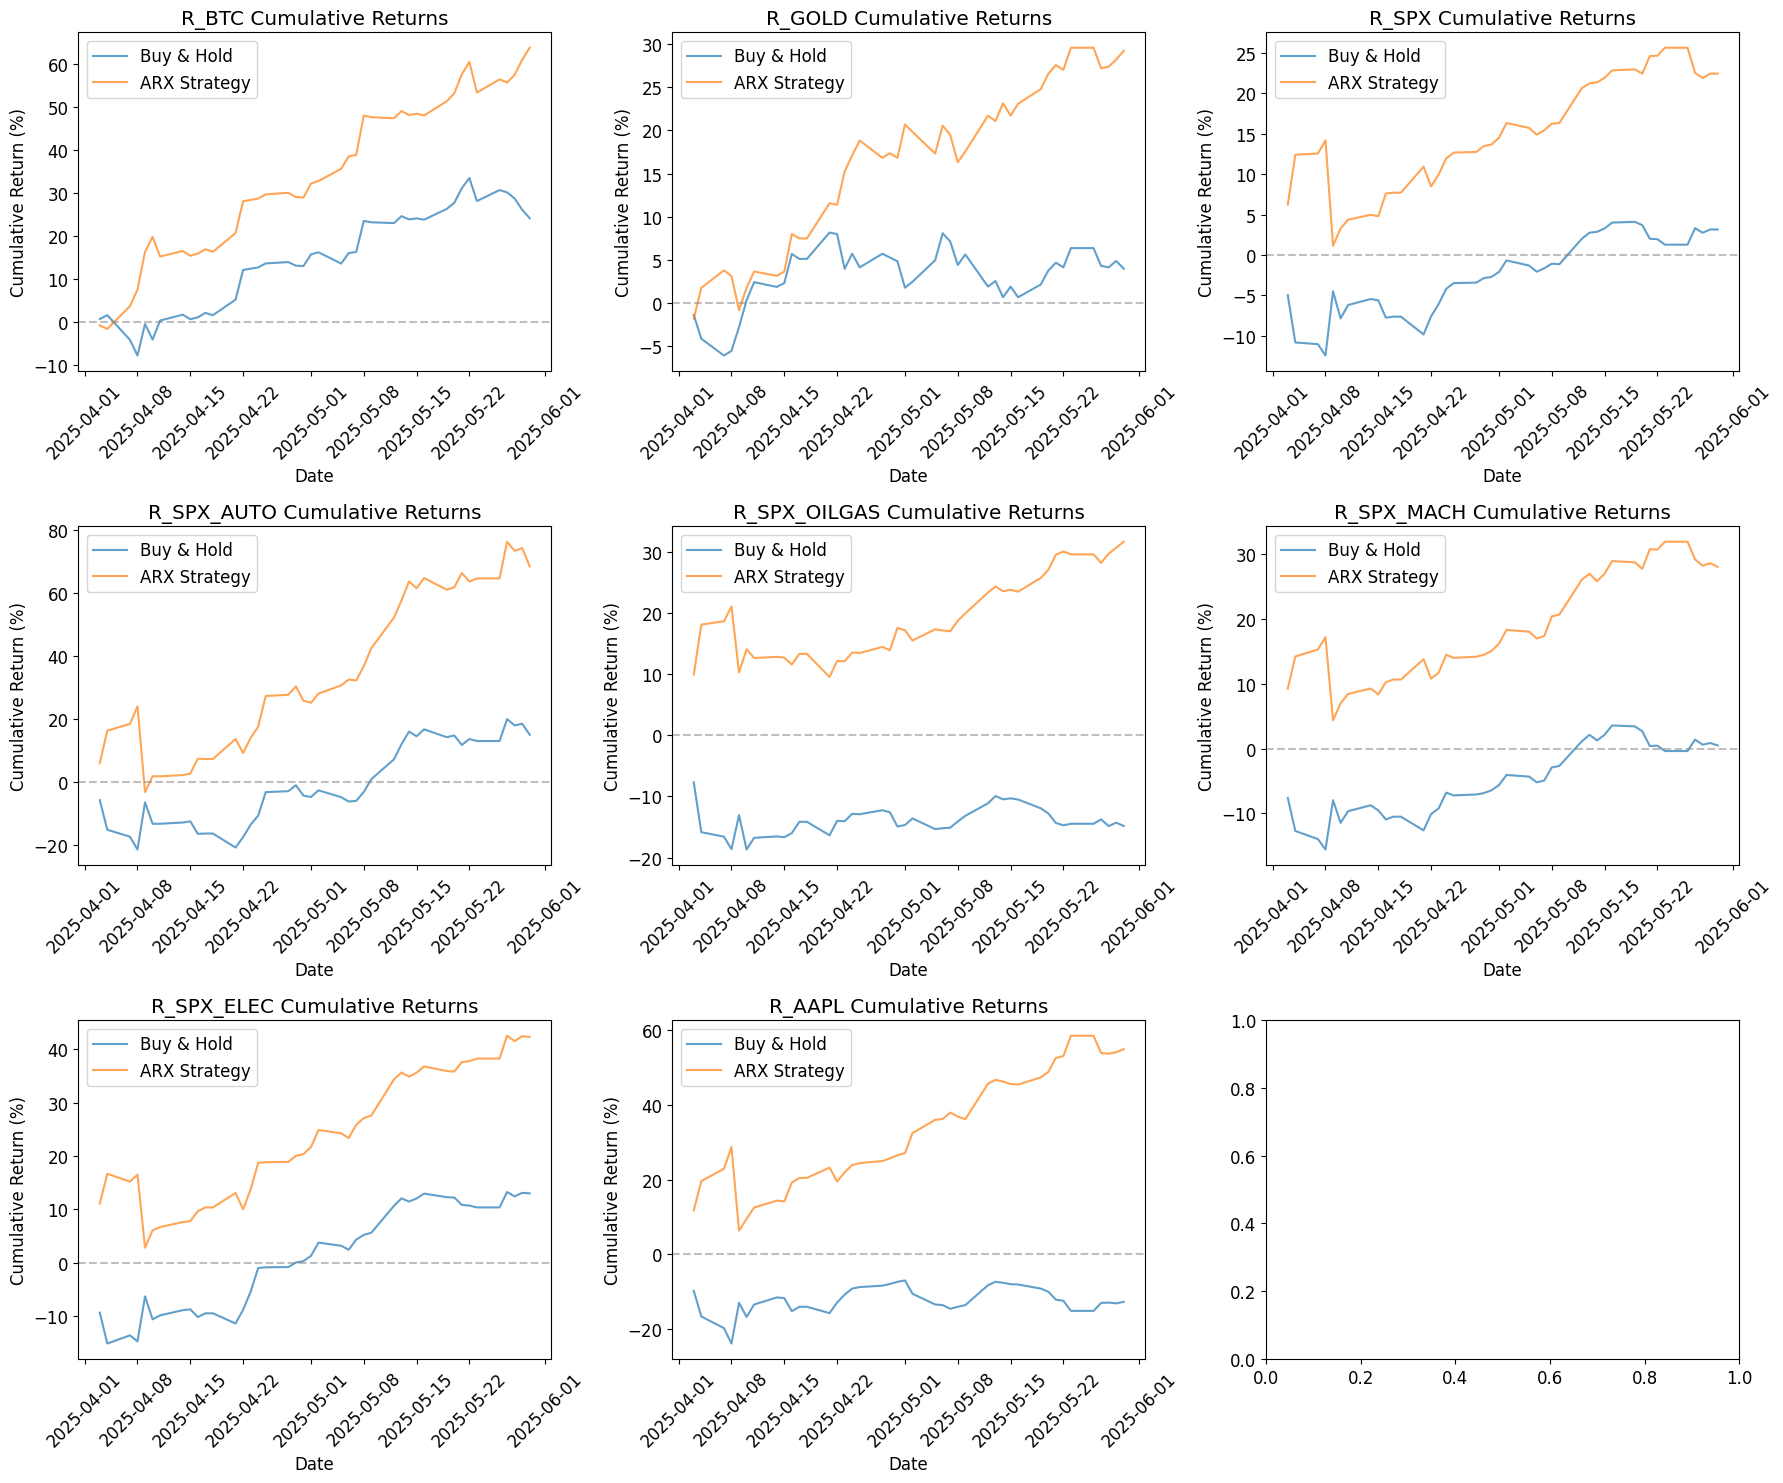


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 24.19%
    Strategy:   63.87%
  r_gold:
    Buy & Hold: 3.99%
    Strategy:   29.23%
  r_spx:
    Buy & Hold: 3.16%
    Strategy:   22.43%
  r_spx_auto:
    Buy & Hold: 15.08%
    Strategy:   68.48%
  r_spx_oilgas:
    Buy & Hold: -14.82%
    Strategy:   31.75%
  r_spx_mach:
    Buy & Hold: 0.48%
    Strategy:   28.07%
  r_spx_elec:
    Buy & Hold: 13.01%
    Strategy:   42.33%
  r_aapl:
    Buy & Hold: -12.65%
    Strategy:   54.77%

Trading Metrics Summary:

R_BTC:
  Sharpe Ratio:     7.917
  Sortino Ratio:    13.828
  Calmar Ratio:     68.554
  Max Drawdown:     -4.45%
  Win Rate:         69.0%
  Profit Factor:    4.65

R_GOLD:
  Sharpe Ratio:     5.303
  Sortino Ratio:    9.952
  Calmar Ratio:     35.688
  Max Drawdown:     -4.45%
  Win Rate:         57.1%
  Profit Factor:    2.34

R_SPX:
  Sharpe Ratio:     3.265
  Sortino Ratio:    2.259
  Calmar Ratio:     11.362
  Max Drawdown:     -11.41%
  Win Rate:         73.8%
  Profit 

In [10]:
# Compute momentum-based trading strategy with volatility scaling
from modules.finance.evaluation.trading_metrics import (
    generate_volatility_scaled_positions,
    compute_trading_metrics
)

cumulative_returns = {}
trading_metrics_all = {}

n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Get asset name
    asset = target.replace('r_', '')
    
    # Get momentum signal (5-day primary) and convert to ±1
    momentum_col = f'momentum_5d_{asset}'
    if momentum_col not in df_clean.columns:
        print(f"Warning: {momentum_col} not found, using sign of predictions")
        momentum_signal = np.sign(preds_df['y_pred'].values)
    else:
        # Align momentum with prediction dates and convert to directional signal
        momentum_values = df_clean.loc[preds_df.index, momentum_col].values
        momentum_signal = np.sign(momentum_values)  # Convert to ±1
    
    # Get signed actual returns (MUST use signed column, not y_true which is absolute)
    signed_col = f'r_{asset}_signed'
    if signed_col in df_clean.columns:
        actual_signed_returns = df_clean.loc[preds_df.index, signed_col].values
    else:
        # Fallback: convert absolute returns to signed using momentum
        print(f"Warning: {signed_col} not found, reconstructing from absolute returns")
        actual_signed_returns = preds_df['y_true'].values * momentum_signal
    
    # Generate volatility-scaled positions
    # y_pred contains predicted volatility (absolute returns), use for inverse vol weighting
    predicted_volatility = preds_df['y_pred'].values
    positions = generate_volatility_scaled_positions(
        momentum_signals=momentum_signal,
        predicted_volatility=predicted_volatility,
        percentile_cap=95,
        percentile_floor=5
    )
    
    # Strategy returns (position * actual signed return)
    strategy_returns = positions * actual_signed_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_signed_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Compute trading metrics
    trading_metrics = compute_trading_metrics(
        strategy_returns=strategy_returns,
        buy_hold_returns=actual_signed_returns
    )
    trading_metrics_all[target] = trading_metrics
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='ARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'varx_baseline_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    Strategy:   {data['final_strategy']*100:.2f}%")

print("\nTrading Metrics Summary:")
for target, metrics in trading_metrics_all.items():
    print(f"\n{target.upper()}:")
    print(f"  Sharpe Ratio:     {metrics['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:    {metrics['sortino_ratio']:.3f}")
    print(f"  Calmar Ratio:     {metrics['calmar_ratio']:.3f}")
    print(f"  Max Drawdown:     {metrics['max_drawdown']*100:.2f}%")

    print(f"  Win Rate:         {metrics['win_rate']*100:.1f}%")
    print(f"  Profit Factor:    {metrics['profit_factor']:.2f}")

## Cross-Asset Spillover Coefficients

Analyze the cross-asset spillover coefficients to understand how different assets influence each other.

In [11]:
# Extract and visualize cross-asset spillover coefficients
print("Cross-Asset Spillover Coefficients")
print("="*60)

# For VARX with MultiTaskElasticNet, we need to handle per-target analysis
# The coefficient matrix from the fitted model gives us cross-asset relationships
coef_matrix = varx_results['coef_matrix']

# Bootstrap analysis for coefficient significance (per target)
bootstrap_results = {}

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    y_target = Y_design[target].values
    
    # Create a single-target pipeline for bootstrap (step name must be 'model')
    from sklearn.linear_model import ElasticNet
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    
    single_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=varx_results['best_model_params']['alpha'],
            l1_ratio=varx_results['best_model_params']['l1_ratio'],
            max_iter=20000
        ))
    ])
    single_pipe.fit(Z_design.values, y_target)
    
    ci_df = bootstrap_coefficient_ci(
        X=Z_design.values,
        y=y_target,
        pipeline=single_pipe,
        feature_names=feature_names,
        n_iter=500,
        alpha_levels=[0.01, 0.05, 0.10],
    )
    
    bootstrap_results[target] = ci_df
    
    # Show cross-asset coefficients
    print(f"  Cross-asset spillover coefficients (significant at α=0.10):")
    sig_features = ci_df[ci_df['stars'] != '']
    cross_asset_found = False
    for feat_name in sig_features.index:
        # Check if it's a cross-asset lag (not own lag)
        is_cross_asset = any(other in feat_name for other in TARGET_COLS if other != target)
        if is_cross_asset:
            row = sig_features.loc[feat_name]
            print(f"    {feat_name}: {row['coef']:.6f} (p={row['pvalue']:.4f}) {row['stars']}")
            cross_asset_found = True
    if not cross_asset_found:
        print("    None significant")

Cross-Asset Spillover Coefficients

Bootstrap analysis for r_btc...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_gold...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_spx...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_spx_auto...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_spx_oilgas...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_spx_mach...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_spx_elec...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant

Bootstrap analysis for r_aapl...
  Cross-asset spillover coefficients (significant at α=0.10):
    None significant


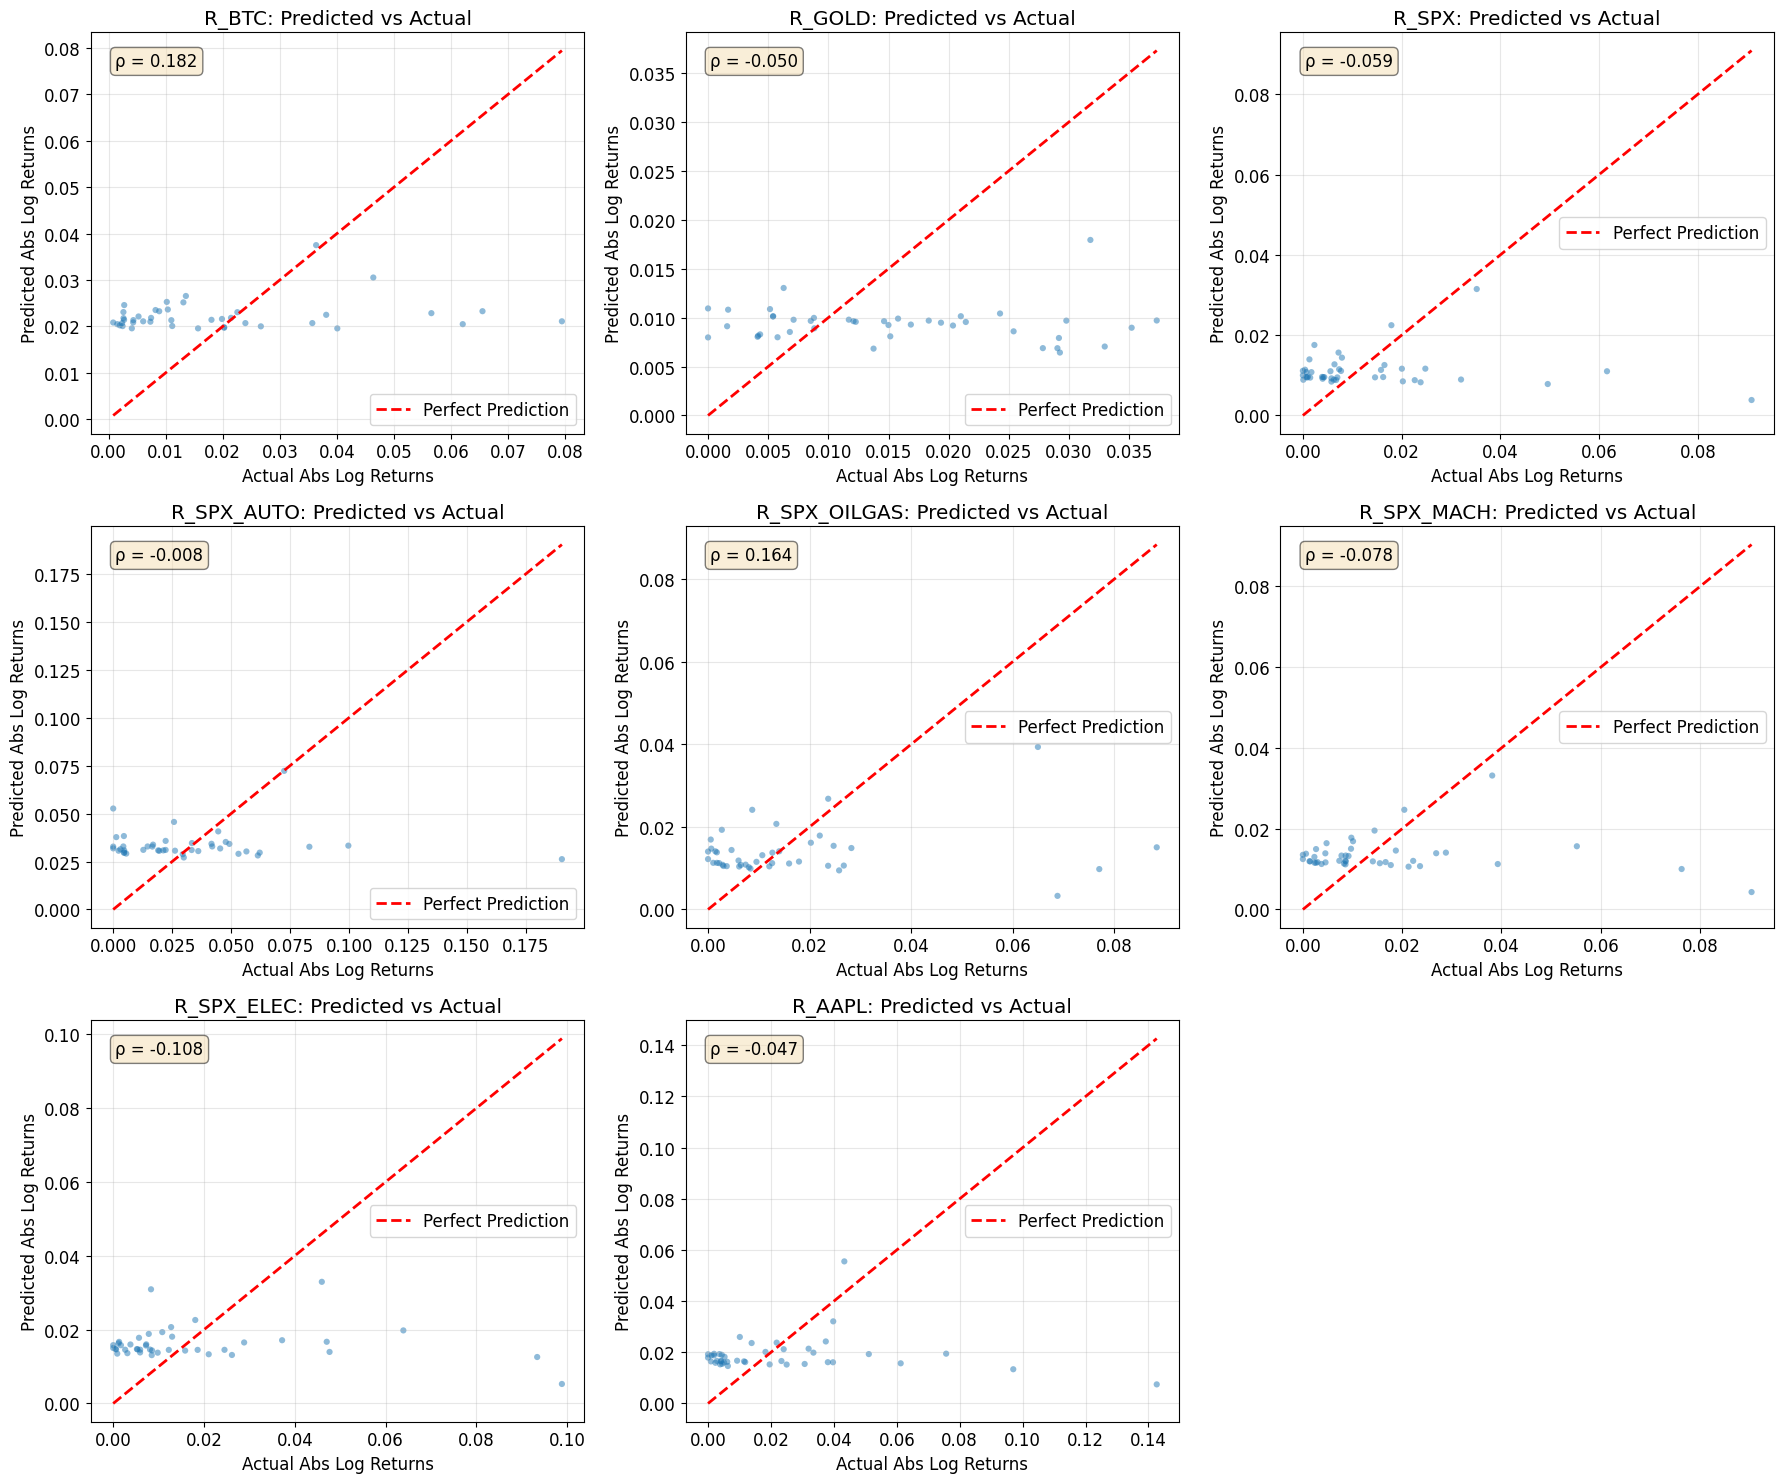


Correlation between predicted and actual:
  r_btc: 0.1817
  r_gold: -0.0502
  r_spx: -0.0589
  r_spx_auto: -0.0085
  r_spx_oilgas: 0.1637
  r_spx_mach: -0.0783
  r_spx_elec: -0.1080
  r_aapl: -0.0471


In [12]:
# Plot predicted vs actual absolute log returns
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    preds_df = oos_predictions[target]
    
    # Scatter plot
    ax.scatter(preds_df['y_true'], preds_df['y_pred'], alpha=0.5, s=20, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(preds_df['y_true'].min(), preds_df['y_pred'].min())
    max_val = max(preds_df['y_true'].max(), preds_df['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Abs Log Returns')
    ax.set_ylabel('Predicted Abs Log Returns')
    ax.set_title(f'{target.upper()}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    ax.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation between predicted and actual:")
for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    print(f"  {target}: {corr:.4f}")

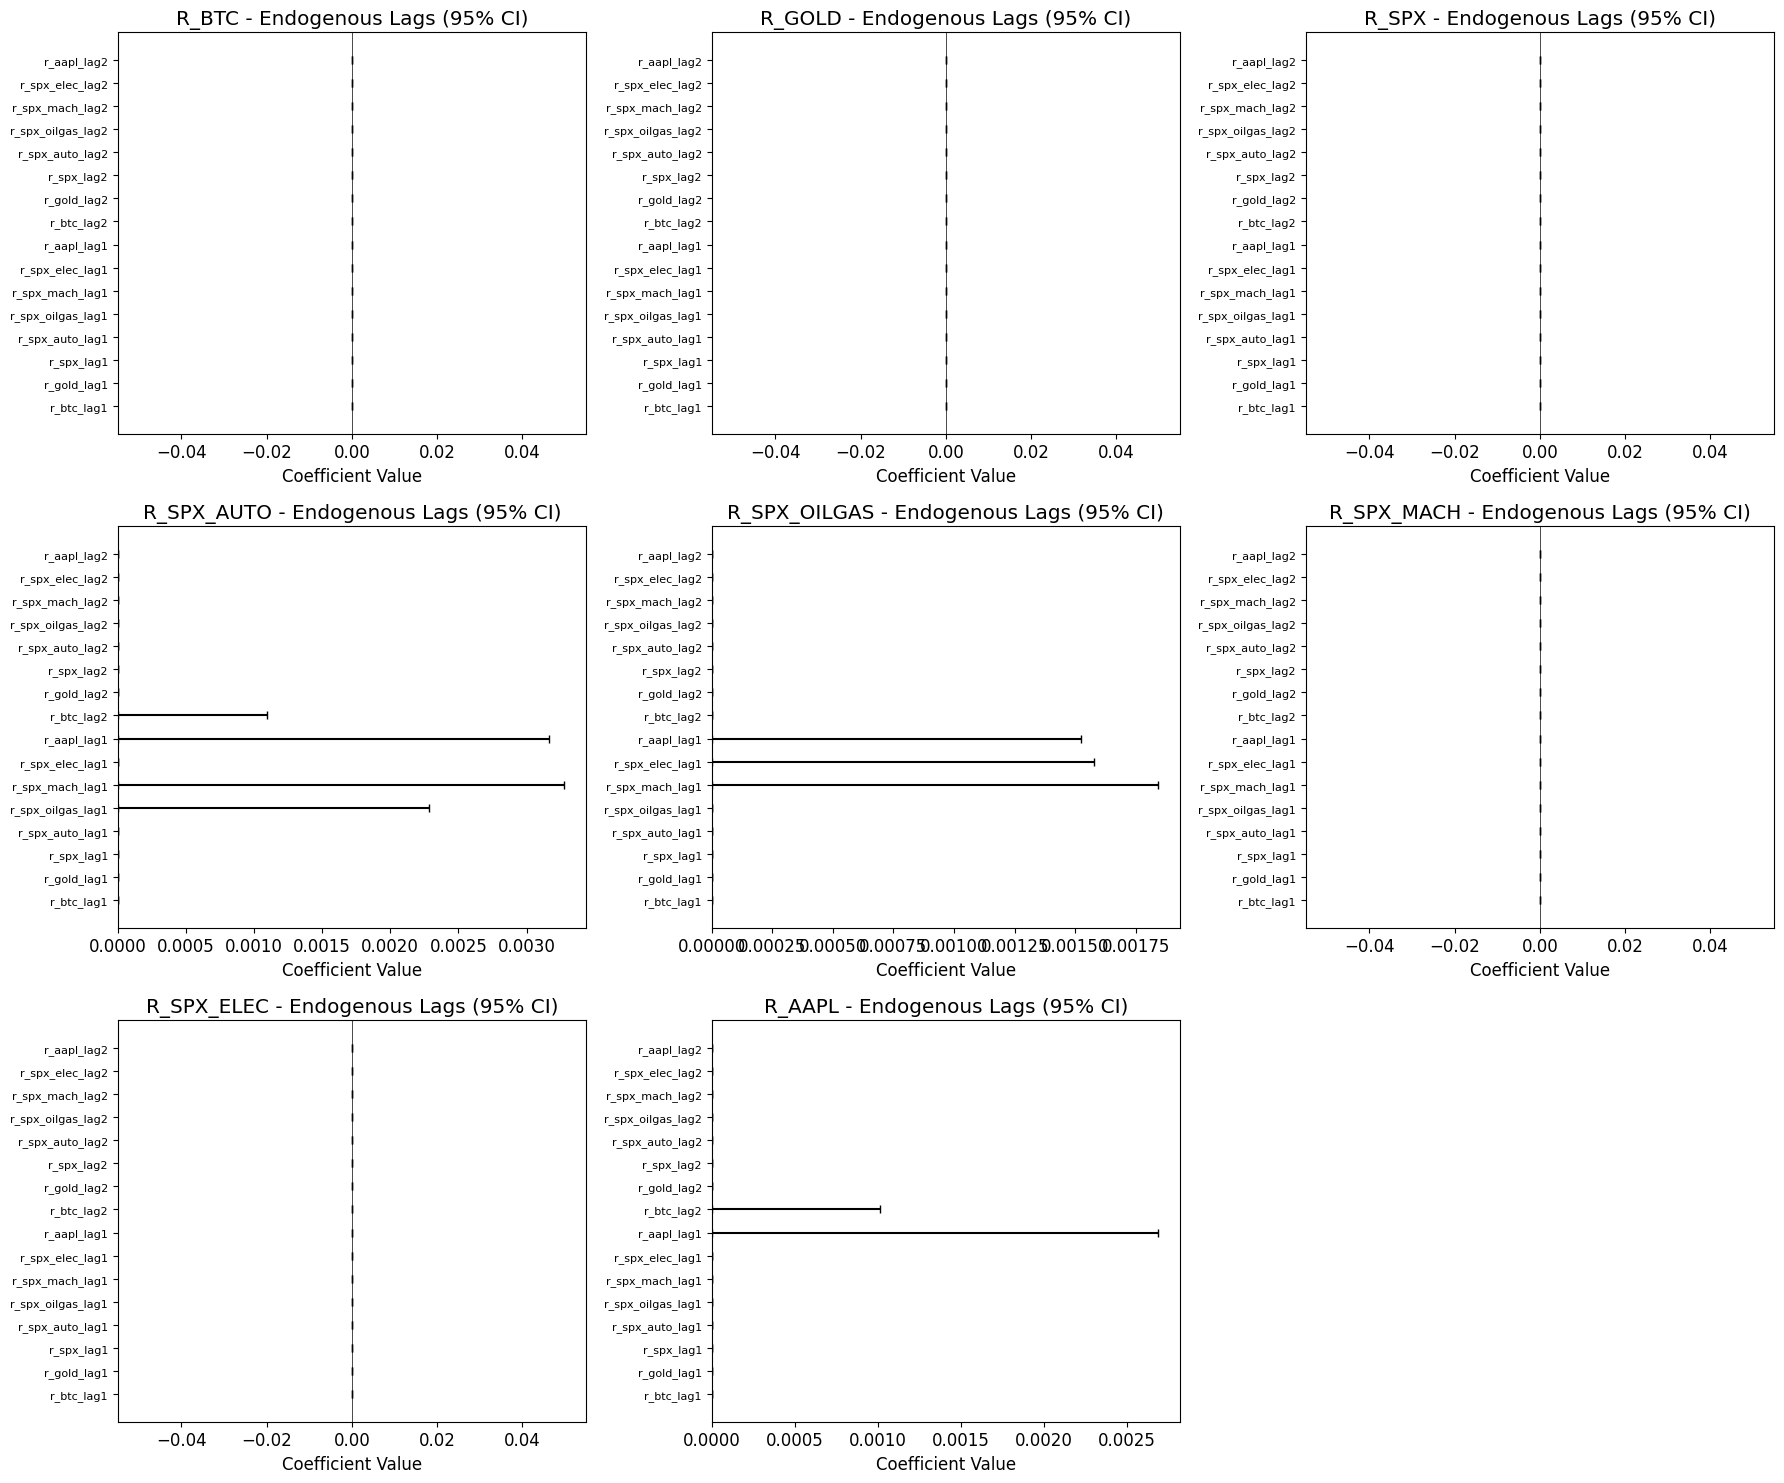

In [13]:
# Visualize spillover matrix
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    ci_df = bootstrap_results[target]
    
    # Filter to show only endogenous lag features
    endog_features = [f for f in feature_names if any(t in f for t in TARGET_COLS)]
    
    features = [f for f in endog_features if f in ci_df.index]
    means = ci_df.loc[features, 'coef'].values
    
    # Get 95% CI bounds
    ci_lower = ci_df.loc[features, 'ci_lower_95'].values if 'ci_lower_95' in ci_df.columns else means - ci_df.loc[features, 'se'].values * 1.96
    ci_upper = ci_df.loc[features, 'ci_upper_95'].values if 'ci_upper_95' in ci_df.columns else means + ci_df.loc[features, 'se'].values * 1.96
    significant = ci_df.loc[features, 'sig_95'].values if 'sig_95' in ci_df.columns else [False] * len(means)
    
    errors = [np.abs(means - ci_lower), np.abs(ci_upper - means)]
    
    colors = ['steelblue' if sig else 'lightgray' for sig in significant]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, means, xerr=errors, color=colors, capsize=3, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'{target.upper()} - Endogenous Lags (95% CI)')

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'varx_baseline_spillover_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

Save all VARX baseline results for later comparison with emotion-enhanced models.

In [14]:
# Save metrics summary
metrics_output = []
for target in TARGET_COLS:
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'VARX_baseline',
        'p': varx_results['best_lags'].p,
        'q_controls': varx_results['best_lags'].q_controls,
        'cv_mae': varx_results['cv_mae'],
        'cv_rmse': varx_results['cv_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'oos_r2': oos['r2'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

metrics_output_df = pd.DataFrame(metrics_output)
metrics_output_df.to_csv(OUTPUT_DIR / 'varx_baseline_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'varx_baseline_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'varx_baseline_predictions_{target}.csv')
print(f"Saved predictions to {OUTPUT_DIR}")

# Save bootstrap results
bootstrap_output = []
for target in TARGET_COLS:
    ci_df = bootstrap_results[target]
    for feat_name in ci_df.index:
        row = ci_df.loc[feat_name]
        bootstrap_output.append({
            'asset': target,
            'feature': feat_name,
            'coef': row['coef'],
            'se': row.get('se', np.nan),
            'pvalue': row.get('pvalue', np.nan),
            'stars': row.get('stars', ''),
            'ci_lower_95': row.get('ci_lower_95', np.nan),
            'ci_upper_95': row.get('ci_upper_95', np.nan),
            'sig_95': row.get('sig_95', False),
        })

bootstrap_df = pd.DataFrame(bootstrap_output)
bootstrap_df.to_csv(OUTPUT_DIR / 'varx_baseline_bootstrap.csv', index=False)
print(f"Saved bootstrap results to {OUTPUT_DIR / 'varx_baseline_bootstrap.csv'}")

print("\n✅ All baseline VARX results saved successfully!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/varx_baseline_metrics.csv
Saved predictions to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim
Saved bootstrap results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/varx_baseline_bootstrap.csv

✅ All baseline VARX results saved successfully!
